In [14]:
# Install necessary libraries if you are running this notebook for the first time
%pip install pandas numpy matplotlib seaborn scikit-learn

# Output a detailed report of the installed libraries and their versions
%pip show pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Name: pandas
Version: 3.0.1
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-2026, Open source contributors.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contribut

# End-to-End Machine Learning Project: Predicting Medical Insurance Costs

Welcome to this introductory Machine Learning project! In this notebook, we will follow the pedagogical style of **Hands-On Machine Learning (Part 1)** to build a regression model that predicts medical insurance charges based on personal attributes.

## 1. Introduction
We will use the **Medical Cost Personal Datasets**. It contains features like age, sex, BMI, number of children, smoking status, and region to predict the insurance `charges`.
- **Problem:** Supervised Learning (Regression)
- **Why suitable?** It is tabular, contains a mix of categorical and numerical features, and requires clear preprocessing (scaling, encoding) before training models like Linear Regression or Random Forests. It is intuitive and accessible.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make this notebook's output stable across runs
np.random.seed(42)

# Plot formatting
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
sns.set_theme(style='whitegrid')

## 2. Data Loading
We can download the dataset directly from a public GitHub repository hosting Kaggle datasets.

In [18]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
insurance = pd.read_csv(url)

# Display the dataset.
# Previously, insurance.head() was used, which by default only returns the first 5 rows.
# By just calling the dataframe variable 'insurance', Jupyter/VS Code renders it as a more interactive and scrollable table showing both start and tail rows!
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## 3. Exploratory Data Analysis (EDA)
Let's understand our features and target variable (`charges`).

In [19]:
# Summary statistics for numerical attributes
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [20]:
# Check for missing values
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


> *Insight:* There are 1338 instances and 0 missing values. Great! The categorical features are `sex`, `smoker`, and `region`.

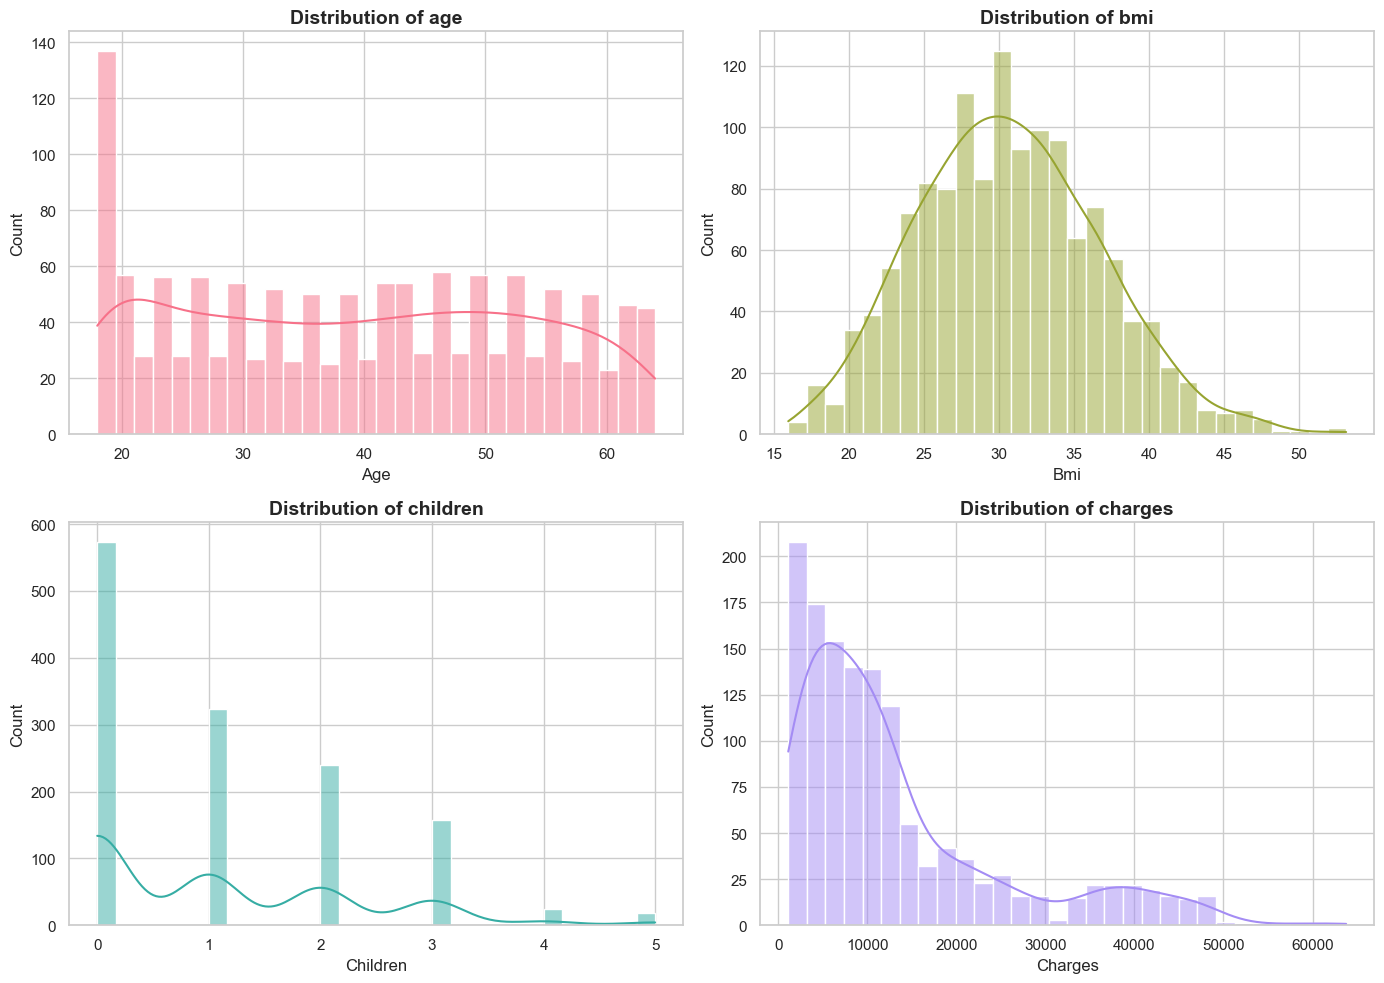

In [21]:
# Visualizing distributions
# We use Seaborn's histplot with a colorful palette and Kernel Density Estimate (KDE) lines for a modern look
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

numeric_cols = insurance.select_dtypes(include=[np.number]).columns
colors = sns.color_palette("husl", len(numeric_cols))

for i, col in enumerate(numeric_cols):
    sns.histplot(insurance[col], kde=True, ax=axes[i], color=colors[i], bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col.capitalize(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
plt.tight_layout()
plt.show()

> *Insight:* `charges` is heavily right-skewed. Most people have lower medical costs, but a tail exists for very high costs. `bmi` looks normally distributed.

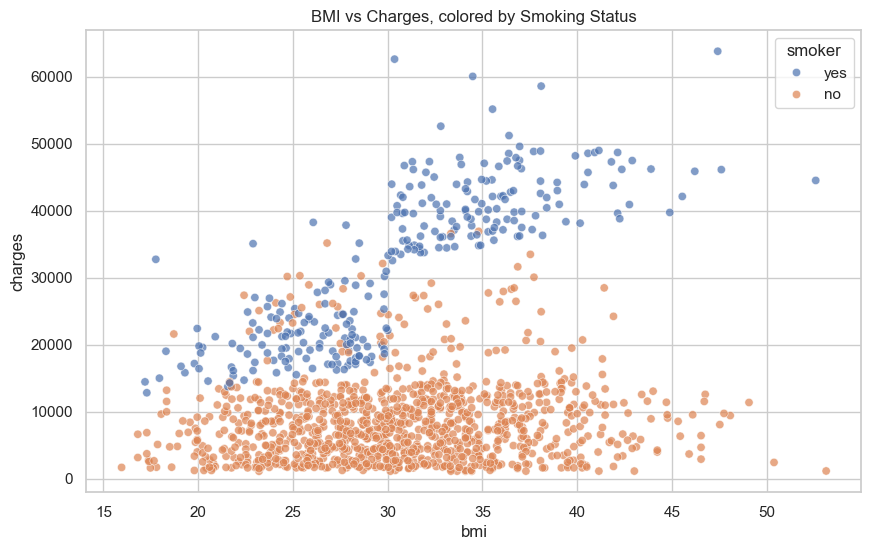

In [22]:
# Creating a scatterplot to see relationships with the target
plt.figure(figsize=(10, 6))
sns.scatterplot(data=insurance, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('BMI vs Charges, colored by Smoking Status')
plt.show()

> *Insight:* Smoking clearly separates the data! Smokers with high BMI have exponentially higher medical charges. This indicates `smoker` is a crucial feature.

Let's also look at the correlation matrix.

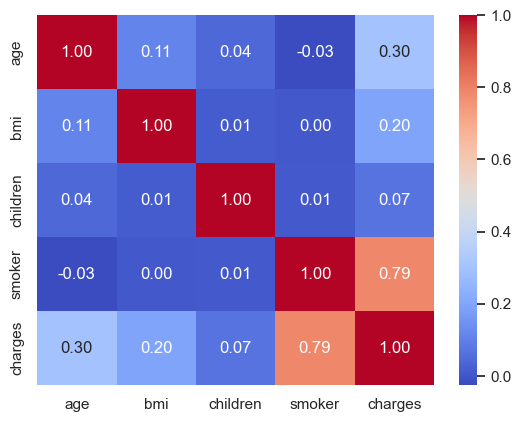

In [23]:
# We'll encode 'smoker' temporarily just to see numerical correlation
corr_df = insurance.copy()
corr_df['smoker'] = corr_df['smoker'].map({'yes': 1, 'no': 0})
corr_mat = corr_df[['age', 'bmi', 'children', 'smoker', 'charges']].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## 4. Data Preprocessing
Let's split the data, and build a Scikit-Learn Pipeline to handle scaling and encoding.

In [24]:
from sklearn.model_selection import train_test_split

X = insurance.drop('charges', axis=1)
y = insurance['charges']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_attribs = ['age', 'bmi', 'children']
cat_attribs = ['sex', 'smoker', 'region']

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

## 5. Modeling
We'll try **Linear Regression**, **Decision Tree**, and **Random Forest**.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_prepared, y_train)

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_prepared, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 6. Model Evaluation
Let's use Root Mean Squared Error (RMSE) and Cross-Validation to evaluate.

In [27]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

def display_scores(model, X, y):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=10)
    rmse_scores = np.sqrt(-scores)
    print(f"{model.__class__.__name__}:")
    print(f"  Mean RMSE = {rmse_scores.mean():.2f}")
    print(f"  Std Dev   = {rmse_scores.std():.2f}\n")

display_scores(lin_reg, X_train_prepared, y_train)
display_scores(tree_reg, X_train_prepared, y_train)
display_scores(forest_reg, X_train_prepared, y_train)

LinearRegression:
  Mean RMSE = 6133.08
  Std Dev   = 520.72

DecisionTreeRegressor:
  Mean RMSE = 6768.44
  Std Dev   = 534.19

RandomForestRegressor:
  Mean RMSE = 4957.13
  Std Dev   = 506.42



> *Insight:* Random Forest performs the best overall (lowest Mean RMSE). The Decision Tree is overfitting heavily (worse validation score than Random Forest). Linear Regression is decent but Random Forest captures nonlinear interactions (like the smoking/BMI relationship seen in EDA).

## 7. Hyperparameter Tuning
Let's fine-tune our Random Forest using `GridSearchCV`.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [30, 50, 100], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]}
]

forest_reg_tune = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg_tune, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_prepared, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best parameters: {'max_features': 4, 'n_estimators': 100}


## 8. Final Model & Interpretation
We evaluate our final selected and tuned model on the Test Set.

In [13]:
final_predictions = best_model.predict(X_test_prepared)
final_rmse = mean_squared_error(y_test, final_predictions, squared=False)
print(f"Final Test RMSE: {final_rmse:.2f}")

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
# Feature Importances
feature_importances = best_model.feature_importances_

# Get feature names from the pipeline
cat_encoder = preprocessing.named_transformers_['cat'].named_steps['encoder']
cat_one_hot_attribs = list(cat_encoder.get_feature_names_out(cat_attribs))
attributes = num_attribs + cat_one_hot_attribs

sorted_importances = sorted(zip(feature_importances, attributes), reverse=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[0] for x in sorted_importances], y=[x[1] for x in sorted_importances], palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.show()

> *Insight:* `smoker_yes` is overwhelmingly the most important feature, followed by `bmi` and `age`. This aligns perfectly with our earlier EDA!

## 9. Conclusion
- **Summary:** We successfully explored the Medical Insurance dataset and built a Random Forest Regressor to predict charges. Over 60% of the model's predictive power comes from knowing whether a patient smokes.
- **Limitations:** The model may struggle with extreme outliers (exceedingly rare medical conditions not represented in generic features). The dataset is relatively small, which limits the diversity of cases.
- **Extensions:** We could explore feature engineering (e.g., categorizing BMI into bins like "Obese" vs "Normal" and creating interactions with 'smoker'.)